In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
import rasterio

from shapely.geometry import LineString
from mpl_toolkits.basemap import Basemap


In [2]:
dates = ['D20110108-T', 'D20110109-T', 'D20110110-T', 'D20110111-T', 'D20110112-T', 'D20110113-T']

In [3]:
coords = []
for date in dates:
    fileName = date + '.csv'
    df = pd.read_csv('../data/coords/' + fileName)
    coords.append(df)
coords = pd.concat(coords, ignore_index=True)
coords['ping_time'] = pd.to_datetime(coords['ping_time'])
coords['date'] = coords['ping_time'].dt.date

coords_gpd = gpd.GeoDataFrame(coords, geometry=gpd.points_from_xy(coords['longitude'], coords['latitude']), crs='EPSG:4326')
coords_gpd['date'] = pd.to_datetime(coords_gpd['date'])
coords_gpd.to_csv('../data/coords/coords_combined_gpd.csv', index=False)

In [4]:
lines = coords_gpd.groupby(['date'])['geometry'].apply(lambda x: LineString(x.tolist()))

In [4]:
boundaries = {
    'lon_min': min(coords['longitude']),
    'lon_max': max(coords['longitude']),
    'lat_min': min(coords['latitude']),
    'lat_max': max(coords['latitude'])
}


In [5]:

coords_gpd['date_str'] = coords_gpd['date'].dt.strftime("%Y-%m-%d")

unique_dates = coords_gpd['date_str'].unique()
palette = plt.cm.tab20   # categorical palette
color_map = {d: palette(i % palette.N) for i, d in enumerate(unique_dates)}



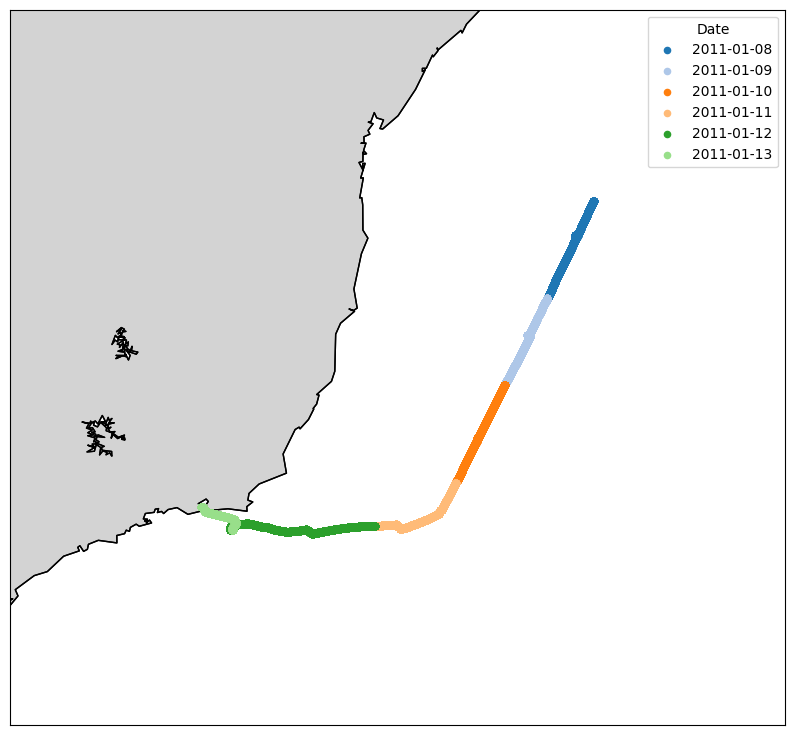

In [6]:
# 1. Prepare categorical dates
coords_gpd['date'] = pd.to_datetime(coords_gpd['date'])
coords_gpd['date_str'] = coords_gpd['date'].dt.strftime("%Y-%m-%d")

# 2. Build color map
unique_dates = coords_gpd['date_str'].unique()
palette = plt.cm.tab20
color_map = {d: palette(i % palette.N) for i, d in enumerate(unique_dates)}

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111)

m = Basemap(
    projection='cyl',           # Plate Carrée so boundaries work
    llcrnrlon=boundaries['lon_min'] -5,
    urcrnrlon=boundaries['lon_max'] +5,
    llcrnrlat=boundaries['lat_min'] -5,
    urcrnrlat=boundaries['lat_max'] +5,
    resolution='l',
    ax=ax
)

m.drawcoastlines()
m.drawcountries()
m.fillcontinents(color='lightgray')
# 3. Draw map
m.drawcoastlines()
m.drawcountries()
m.fillcontinents(color='lightgray')

# 4. PLOT inside a loop — this is the only valid place to use date_val
for date_val in unique_dates:
    subset = coords_gpd[coords_gpd['date_str'] == date_val]

    m.scatter(
        subset['longitude'], subset['latitude'],
        latlon=True,
        s=20,
        color=color_map[date_val],   # <-- now date_val exists
        edgecolor=None,
        label=date_val,
        zorder=10
    )

# 5. Legend
plt.legend(title="Date")
plt.show()